# 02 – Modeling & Evaluation (Baseline)
**Projekt:** StepSense | ML4B SoSe 2026 | Gruppe: NoNames
**CRISP-DM Phasen:** Modeling + Evaluation

## Inhalt
1. Imports & Konfiguration
2. Daten laden
3. Baseline-Modell (Decision Tree)
4. Modellvergleich mit Cross-Validation
5. Bestes Modell – finale Evaluation
6. Konfusionsmatrix & Per-Klasse Metriken
7. Feature Importance
8. Modell exportieren
9. Mixed-Evaluation
10. Zusammenfassung & Bias-Diskussion


## 1. Imports & Konfiguration

In [1]:
import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, HistGradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

warnings.filterwarnings("ignore")

PROCESSED_PATH = "../data/processed"
MIXED_PATH     = "../data/mixed"
RANDOM_STATE   = 42

SENSOR_PREFIX = {
    "Accelerometer": "acc",
    "Gyroscope":     "gyro",
    "Orientation":   "orie",
}
SENSOR_COLUMNS = {
    "Accelerometer": ["x", "y", "z"],
    "Gyroscope":     ["x", "y", "z"],
    "Orientation":   ["roll", "pitch", "yaw"],
}

print("Setup abgeschlossen.")


Setup abgeschlossen.


## 2. Daten laden

In [2]:
# Feature-Namen laden
with open(f"{PROCESSED_PATH}/feature_names.txt") as f:
    feature_cols = [line.strip() for line in f.readlines()]

# Scaler laden (wird in Mixed-Eval benoetigt)
with open(f"{PROCESSED_PATH}/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# Session-Split laden
with open(f"{PROCESSED_PATH}/session_split.json") as f:
    session_split = json.load(f)
train_sessions = session_split["train"]
val_sessions   = session_split["val"]
test_sessions  = session_split["test"]

# Alle unskalierten Features laden (CV skaliert intern je Fold via Pipeline)
df_all = pd.read_csv(f"{PROCESSED_PATH}/features_all.csv")

# Unskalierte Train+Val Daten fuer GroupKFold-CV
mask_tv         = df_all["session"].isin(train_sessions + val_sessions)
X_trainval_raw  = df_all.loc[mask_tv, feature_cols].reset_index(drop=True)
y_trainval      = df_all.loc[mask_tv, "label"].reset_index(drop=True)

# Groups aus Datei laden (gleiche Reihenfolge wie X_trainval_raw – exportiert von NB01)
groups_trainval = pd.read_csv(f"{PROCESSED_PATH}/groups_trainval.csv").squeeze()

# Unskalierte Test-Daten fuer finale Evaluation
mask_te    = df_all["session"].isin(test_sessions)
X_test_raw = df_all.loc[mask_te, feature_cols].reset_index(drop=True)
y_test     = df_all.loc[mask_te, "label"].reset_index(drop=True)

# Skalierte Splits (nur fuer Baseline Decision Tree in Abschnitt 3)
X_train = pd.read_csv(f"{PROCESSED_PATH}/X_train.csv")
X_val   = pd.read_csv(f"{PROCESSED_PATH}/X_val.csv")
y_train = pd.read_csv(f"{PROCESSED_PATH}/y_train.csv").squeeze()
y_val   = pd.read_csv(f"{PROCESSED_PATH}/y_val.csv").squeeze()

print(f"Features:         {len(feature_cols)}")
print(f"Train+Val (roh):  {len(X_trainval_raw):>5} Fenster x {X_trainval_raw.shape[1]} Features | {groups_trainval.nunique()} Sessions")
print(f"Test      (roh):  {len(X_test_raw):>5} Fenster")
assert len(groups_trainval) == len(X_trainval_raw), \
    f"Alignment-Fehler: groups_trainval ({len(groups_trainval)}) != X_trainval_raw ({len(X_trainval_raw)})"
print("Alignment groups_trainval <-> X_trainval_raw: OK")
print(f"\nKlassenverteilung Train+Val:")
print(y_trainval.value_counts().sort_index().to_string())


Features:         81
Train+Val (roh):   3166 Fenster x 81 Features | 41 Sessions
Test      (roh):    455 Fenster
Alignment groups_trainval <-> X_trainval_raw: OK

Klassenverteilung Train+Val:
label
Gehen            884
Laufen           729
Liegen           710
Stehen           368
Treppe_hoch      205
Treppe_runter    270


## 3. Baseline-Modell – Decision Tree

Ein einfacher Decision Tree als Ausgangspunkt (Baseline).  
Kein Hyperparameter-Tuning — Standardeinstellungen mit `class_weight='balanced'` wegen Klassenungleichgewicht.


In [3]:
baseline = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE
)
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_val)
acc_baseline = accuracy_score(y_val, y_pred_baseline)
f1_baseline  = f1_score(y_val, y_pred_baseline, average="weighted")

print(f"=== Baseline: Decision Tree ===")
print(f"Accuracy (Val):          {acc_baseline:.4f}")
print(f"F1 gewichtet (Val):      {f1_baseline:.4f}")
print()
print(classification_report(y_val, y_pred_baseline, zero_division=0))


=== Baseline: Decision Tree ===
Accuracy (Val):          0.8489
F1 gewichtet (Val):      0.8470

               precision    recall  f1-score   support

        Gehen       0.59      0.30      0.40        54
       Laufen       0.98      0.99      0.99       160
       Liegen       0.99      1.00      0.99       138
       Stehen       0.99      0.98      0.99       123
  Treppe_hoch       0.65      0.30      0.41        37
Treppe_runter       0.31      0.61      0.41        44

     accuracy                           0.85       556
    macro avg       0.75      0.70      0.70       556
 weighted avg       0.87      0.85      0.85       556



## 4. Modellvergleich – Cross-Validation

5-fache Stratified Cross-Validation auf Train+Val.  
Metriken: gewichtetes F1 (Hauptmetrik wegen Klassenungleichgewicht) und Accuracy.


In [4]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler as SS
from sklearn.utils.class_weight import compute_sample_weight

# n_splits=3 statt 5: mit 24 Train+Val Sessions und nur 2 Stehen-Sessions erzeugt
# GroupKFold(5) Folds ohne Stehen im Training -> hohe Varianz und schlechte Generalisierung.
cv = GroupKFold(n_splits=3)

# ── Klassengewichte ───────────────────────────────────────────────────────────
sample_weights = compute_sample_weight(class_weight="balanced", y=y_trainval)
print("Klassengewichte (balanced):")
for cls in sorted(y_trainval.unique()):
    w = sample_weights[y_trainval.values == cls][0]
    n = (y_trainval == cls).sum()
    print(f"  {cls:15s}: Gewicht={w:.3f}  (n={n})")
print()

# ── Modelle in drei Gruppen ───────────────────────────────────────────────────
# Gruppe A: class_weight='balanced' direkt im Classifier
models_cw = {
    "Decision Tree":  Pipeline([("scaler", SS()), ("clf",
        DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE))]),
    "Random Forest":  Pipeline([("scaler", SS()), ("clf",
        RandomForestClassifier(n_estimators=200, class_weight="balanced",
                               random_state=RANDOM_STATE, n_jobs=-1))]),
    "Extra Trees":    Pipeline([("scaler", SS()), ("clf",
        ExtraTreesClassifier(n_estimators=200, class_weight="balanced",
                             random_state=RANDOM_STATE, n_jobs=-1))]),
    "SVM":            Pipeline([("scaler", SS()), ("clf",
        SVC(class_weight="balanced", kernel="rbf", C=10, random_state=RANDOM_STATE,
            probability=True))]),
}
# Gruppe B: sample_weight via params (sklearn >= 1.6, kein class_weight Param)
models_sw = {
    "Gradient Boosting": Pipeline([("scaler", SS()), ("clf",
        GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                   max_depth=4, subsample=0.8,
                                   random_state=RANDOM_STATE))]),
    "HistGB":            Pipeline([("scaler", SS()), ("clf",
        HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05,
                                       max_depth=6, l2_regularization=0.1,
                                       random_state=RANDOM_STATE))]),
}
# Gruppe C: KNN – kein Klassengewicht moeglich
models_nw = {
    "KNN": Pipeline([("scaler", SS()), ("clf",
        KNeighborsClassifier(n_neighbors=5, n_jobs=-1))]),
}
models = {**models_cw, **models_sw, **models_nw}

# ── Cross-Validation ──────────────────────────────────────────────────────────
cv_results = {}

for name, pipe in models_cw.items():
    scores = cross_validate(
        pipe, X_trainval_raw, y_trainval,
        groups=groups_trainval, cv=cv,
        scoring={"f1_weighted": "f1_weighted", "accuracy": "accuracy"},
        n_jobs=-1
    )
    cv_results[name] = {
        "F1 gewichtet (mean)": scores["test_f1_weighted"].mean(),
        "F1 gewichtet (std)":  scores["test_f1_weighted"].std(),
        "Accuracy (mean)":     scores["test_accuracy"].mean(),
        "Accuracy (std)":      scores["test_accuracy"].std(),
    }
    print(f"{name:<22} F1={scores['test_f1_weighted'].mean():.4f} ± {scores['test_f1_weighted'].std():.4f}  Acc={scores['test_accuracy'].mean():.4f}  [class_weight]")

for name, pipe in models_sw.items():
    scores = cross_validate(
        pipe, X_trainval_raw, y_trainval,
        groups=groups_trainval, cv=cv,
        scoring={"f1_weighted": "f1_weighted", "accuracy": "accuracy"},
        params={"clf__sample_weight": sample_weights},
        n_jobs=-1
    )
    cv_results[name] = {
        "F1 gewichtet (mean)": scores["test_f1_weighted"].mean(),
        "F1 gewichtet (std)":  scores["test_f1_weighted"].std(),
        "Accuracy (mean)":     scores["test_accuracy"].mean(),
        "Accuracy (std)":      scores["test_accuracy"].std(),
    }
    print(f"{name:<22} F1={scores['test_f1_weighted'].mean():.4f} ± {scores['test_f1_weighted'].std():.4f}  Acc={scores['test_accuracy'].mean():.4f}  [sample_weight]")

for name, pipe in models_nw.items():
    scores = cross_validate(
        pipe, X_trainval_raw, y_trainval,
        groups=groups_trainval, cv=cv,
        scoring={"f1_weighted": "f1_weighted", "accuracy": "accuracy"},
        n_jobs=-1
    )
    cv_results[name] = {
        "F1 gewichtet (mean)": scores["test_f1_weighted"].mean(),
        "F1 gewichtet (std)":  scores["test_f1_weighted"].std(),
        "Accuracy (mean)":     scores["test_accuracy"].mean(),
        "Accuracy (std)":      scores["test_accuracy"].std(),
    }
    print(f"{name:<22} F1={scores['test_f1_weighted'].mean():.4f} ± {scores['test_f1_weighted'].std():.4f}  Acc={scores['test_accuracy'].mean():.4f}  [keine Gewichtung]")

# ── VotingClassifier (Soft Voting der Top-3 Modelle) ─────────────────────────
# ExtraTreesClassifier als separate Estimatoren (VotingClassifier verwaltet Pipelines intern)
top3_names  = sorted(cv_results, key=lambda n: cv_results[n]["F1 gewichtet (mean)"], reverse=True)[:3]
print(f"\nTop-3 fuer Voting: {top3_names}")

voting_clf = VotingClassifier(
    estimators=[(name, models[name]) for name in top3_names],
    voting="soft",
    n_jobs=-1
)
scores_v = cross_validate(
    voting_clf, X_trainval_raw, y_trainval,
    groups=groups_trainval, cv=cv,
    scoring={"f1_weighted": "f1_weighted", "accuracy": "accuracy"},
    n_jobs=1
)
cv_results["Voting (Top3)"] = {
    "F1 gewichtet (mean)": scores_v["test_f1_weighted"].mean(),
    "F1 gewichtet (std)":  scores_v["test_f1_weighted"].std(),
    "Accuracy (mean)":     scores_v["test_accuracy"].mean(),
    "Accuracy (std)":      scores_v["test_accuracy"].std(),
}
print(f"{'Voting (Top3)':<22} F1={scores_v['test_f1_weighted'].mean():.4f} ± {scores_v['test_f1_weighted'].std():.4f}  Acc={scores_v['test_accuracy'].mean():.4f}  [ensemble]")

df_cv = pd.DataFrame(cv_results).T.round(4)
print()
print(df_cv.to_string())


Klassengewichte (balanced):
  Gehen          : Gewicht=0.597  (n=884)
  Laufen         : Gewicht=0.724  (n=729)
  Liegen         : Gewicht=0.743  (n=710)
  Stehen         : Gewicht=1.434  (n=368)
  Treppe_hoch    : Gewicht=2.574  (n=205)
  Treppe_runter  : Gewicht=1.954  (n=270)

Decision Tree          F1=0.8275 ± 0.0364  Acc=0.8292  [class_weight]
Random Forest          F1=0.8103 ± 0.0111  Acc=0.8161  [class_weight]
Extra Trees            F1=0.8367 ± 0.0208  Acc=0.8405  [class_weight]
SVM                    F1=0.7854 ± 0.0194  Acc=0.7940  [class_weight]
Gradient Boosting      F1=0.8413 ± 0.0526  Acc=0.8466  [sample_weight]
HistGB                 F1=0.8136 ± 0.0284  Acc=0.8210  [sample_weight]
KNN                    F1=0.7721 ± 0.0296  Acc=0.7757  [keine Gewichtung]

Top-3 fuer Voting: ['Gradient Boosting', 'Extra Trees', 'Decision Tree']
Voting (Top3)          F1=0.8404 ± 0.0411  Acc=0.8453  [ensemble]

                   F1 gewichtet (mean)  F1 gewichtet (std)  Accuracy (mean)  Accur

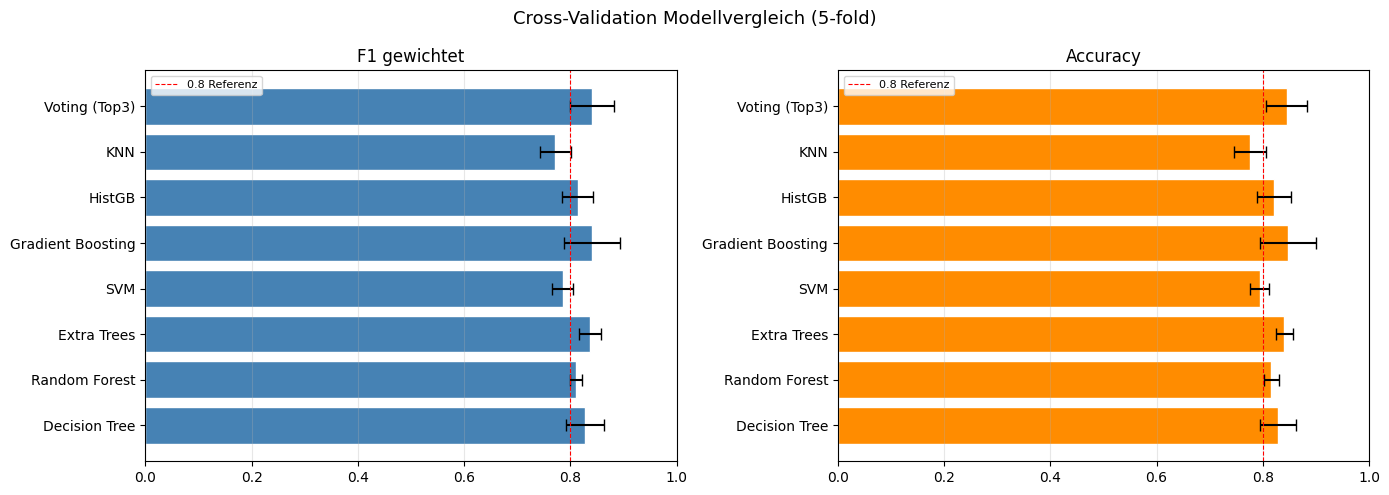

In [5]:
# Modellvergleich visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cross-Validation Modellvergleich (5-fold)", fontsize=13)

names = list(cv_results.keys())
f1_means  = [cv_results[n]["F1 gewichtet (mean)"] for n in names]
f1_stds   = [cv_results[n]["F1 gewichtet (std)"]  for n in names]
acc_means = [cv_results[n]["Accuracy (mean)"]      for n in names]
acc_stds  = [cv_results[n]["Accuracy (std)"]       for n in names]

axes[0].barh(names, f1_means, xerr=f1_stds, color="steelblue", edgecolor="white", capsize=4)
axes[0].set_title("F1 gewichtet")
axes[0].set_xlim(0, 1)
axes[0].axvline(0.8, color="red", linestyle="--", linewidth=0.8, label="0.8 Referenz")
axes[0].legend(fontsize=8)
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(names, acc_means, xerr=acc_stds, color="darkorange", edgecolor="white", capsize=4)
axes[1].set_title("Accuracy")
axes[1].set_xlim(0, 1)
axes[1].axvline(0.8, color="red", linestyle="--", linewidth=0.8, label="0.8 Referenz")
axes[1].legend(fontsize=8)
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PROCESSED_PATH}/model_comparison_cv.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Bestes Modell – Training & finale Evaluation

Das Modell mit dem hoechsten CV F1-Score wird auf dem vollstaendigen Train+Val Datensatz trainiert  
und abschliessend auf dem **Test-Set** evaluiert (einmalig, kein weiteres Tuning).


In [6]:
# Bestes Modell automatisch auswaehlen
best_name = max(cv_results, key=lambda n: cv_results[n]["F1 gewichtet (mean)"])
print(f"Bestes Modell (CV F1): {best_name}")
print(f"  F1 = {cv_results[best_name]['F1 gewichtet (mean)']:.4f} ± {cv_results[best_name]['F1 gewichtet (std)']:.4f}")

# ── Schritt 1: Bestes CV-Modell auf vollem Train+Val trainieren ────────────────
if best_name == "Voting (Top3)":
    voting_clf.fit(X_trainval_raw, y_trainval)
    best_model     = voting_clf
    best_name_final = "Voting (Top3)"
elif best_name in models_sw:
    models[best_name].fit(X_trainval_raw, y_trainval, clf__sample_weight=sample_weights)
    best_model     = models[best_name]
    best_name_final = best_name
else:
    models[best_name].fit(X_trainval_raw, y_trainval)
    best_model     = models[best_name]
    best_name_final = best_name

# ── Schritt 2: Sofortige Test-Evaluation (immer verfuegbar, auch wenn Tuning fehlschlaegt) ──
y_pred_test = best_model.predict(X_test_raw)
acc_test    = accuracy_score(y_test, y_pred_test)
f1_test     = f1_score(y_test, y_pred_test, average="weighted")

print(f"\n=== Test-Evaluation (ohne Tuning): {best_name_final} ===")
print(f"Accuracy:     {acc_test:.4f}")
print(f"F1 gewichtet: {f1_test:.4f}")
print(f"Klassen im Test: {sorted(y_test.unique())}")
print()
print(classification_report(y_test, y_pred_test, labels=sorted(y_test.unique()), zero_division=0))

# ── Schritt 3: RandomizedSearchCV fuer Einzel-Modelle ─────────────────────────
PARAM_GRIDS = {
    "Decision Tree":  {"clf__max_depth": [None, 5, 10, 20],
                       "clf__min_samples_split": [2, 5, 10]},
    "Random Forest":  {"clf__n_estimators": [100, 200, 300],
                       "clf__max_depth":    [None, 10, 20],
                       "clf__max_features": ["sqrt", "log2", 0.3],
                       "clf__min_samples_leaf": [1, 2, 4]},
    "Extra Trees":    {"clf__n_estimators": [100, 200, 300],
                       "clf__max_depth":    [None, 10, 20],
                       "clf__max_features": ["sqrt", "log2", 0.3],
                       "clf__min_samples_leaf": [1, 2, 4]},
    "SVM":            {"clf__C":     [0.1, 1, 10, 50, 100],
                       "clf__gamma": ["scale", "auto", 0.01, 0.001]},
    "Gradient Boosting": {"clf__n_estimators":  [100, 200, 300],
                           "clf__learning_rate": [0.01, 0.05, 0.1],
                           "clf__max_depth":     [3, 4, 5, 6],
                           "clf__subsample":     [0.7, 0.8, 1.0]},
    "HistGB":            {"clf__max_iter":          [100, 200, 300],
                           "clf__learning_rate":     [0.01, 0.05, 0.1],
                           "clf__max_depth":         [None, 4, 6, 8],
                           "clf__l2_regularization": [0, 0.1, 1.0],
                           "clf__min_samples_leaf":  [10, 20, 40]},
}

tune_name = best_name if best_name in PARAM_GRIDS else \
    max([n for n in cv_results if n in PARAM_GRIDS],
        key=lambda n: cv_results[n]["F1 gewichtet (mean)"])

print(f"RandomizedSearchCV fuer: {tune_name}  (n_iter=30) ...")

try:
    rs = RandomizedSearchCV(
        models[tune_name], PARAM_GRIDS[tune_name],
        n_iter=30, cv=cv, scoring="f1_weighted",
        n_jobs=-1, random_state=RANDOM_STATE, refit=True,
        error_score=0.0
    )
    # groups MUSS an fit() uebergeben werden, nicht an den GroupKFold-Konstruktor
    if tune_name in models_sw:
        rs.fit(X_trainval_raw, y_trainval,
               groups=groups_trainval,
               clf__sample_weight=sample_weights)
    else:
        rs.fit(X_trainval_raw, y_trainval, groups=groups_trainval)

    print(f"  Beste Parameter:  {rs.best_params_}")
    print(f"  CV F1 (tuned):    {rs.best_score_:.4f}  vs.  untuned {cv_results[tune_name]['F1 gewichtet (mean)']:.4f}")

    # Modellauswahl nach CV-Score - kein Test-Set-Vergleich
    if rs.best_score_ > cv_results[tune_name]["F1 gewichtet (mean)"]:
        best_model      = rs.best_estimator_
        best_name_final = f"{tune_name} (tuned)"
        print(f"  Tuned Modell (CV F1={rs.best_score_:.4f}) besser -> wird verwendet")
    else:
        print(f"  Untuned Modell gleich gut oder besser (CV F1={cv_results[tune_name]['F1 gewichtet (mean)']:.4f}) -> unveraendert")

except Exception as e:
    print(f"  RandomizedSearchCV fehlgeschlagen: {e}")
    print(f"  Verwende unveraendertes Modell.")

# Test-Evaluation einmalig nach finaler Modellauswahl (kein Test-Set-Shopping)
y_pred_test = best_model.predict(X_test_raw)
acc_test    = accuracy_score(y_test, y_pred_test)
f1_test     = f1_score(y_test, y_pred_test, average="weighted")

print(f"\n=== Finale Test-Evaluation: {best_name_final} ===")
print(f"Accuracy:     {acc_test:.4f}")
print(f"F1 gewichtet: {f1_test:.4f}")


Bestes Modell (CV F1): Gradient Boosting
  F1 = 0.8413 ± 0.0526

=== Test-Evaluation (ohne Tuning): Gradient Boosting ===
Accuracy:     0.9934
F1 gewichtet: 0.9934
Klassen im Test: ['Gehen', 'Laufen', 'Liegen', 'Stehen', 'Treppe_hoch', 'Treppe_runter']

               precision    recall  f1-score   support

        Gehen       0.98      0.99      0.99       122
       Laufen       0.99      1.00      1.00       109
       Liegen       1.00      1.00      1.00       118
       Stehen       1.00      1.00      1.00        32
  Treppe_hoch       1.00      0.95      0.97        38
Treppe_runter       1.00      1.00      1.00        36

     accuracy                           0.99       455
    macro avg       1.00      0.99      0.99       455
 weighted avg       0.99      0.99      0.99       455

RandomizedSearchCV fuer: Gradient Boosting  (n_iter=30) ...
  Beste Parameter:  {'clf__subsample': 0.7, 'clf__n_estimators': 300, 'clf__max_depth': 6, 'clf__learning_rate': 0.05}
  CV F1 (tuned

## 6. Konfusionsmatrix & Per-Klasse Metriken

Fokus auf Treppe_hoch und Treppe_runter (Minderheitsklassen).


In [7]:
# Classification Report
present_classes = sorted(y_test.unique())
print(classification_report(y_test, y_pred_test, labels=present_classes, zero_division=0))


               precision    recall  f1-score   support

        Gehen       0.98      0.98      0.98       122
       Laufen       0.98      1.00      0.99       109
       Liegen       1.00      1.00      1.00       118
       Stehen       1.00      1.00      1.00        32
  Treppe_hoch       1.00      0.97      0.99        38
Treppe_runter       1.00      0.97      0.99        36

     accuracy                           0.99       455
    macro avg       0.99      0.99      0.99       455
 weighted avg       0.99      0.99      0.99       455



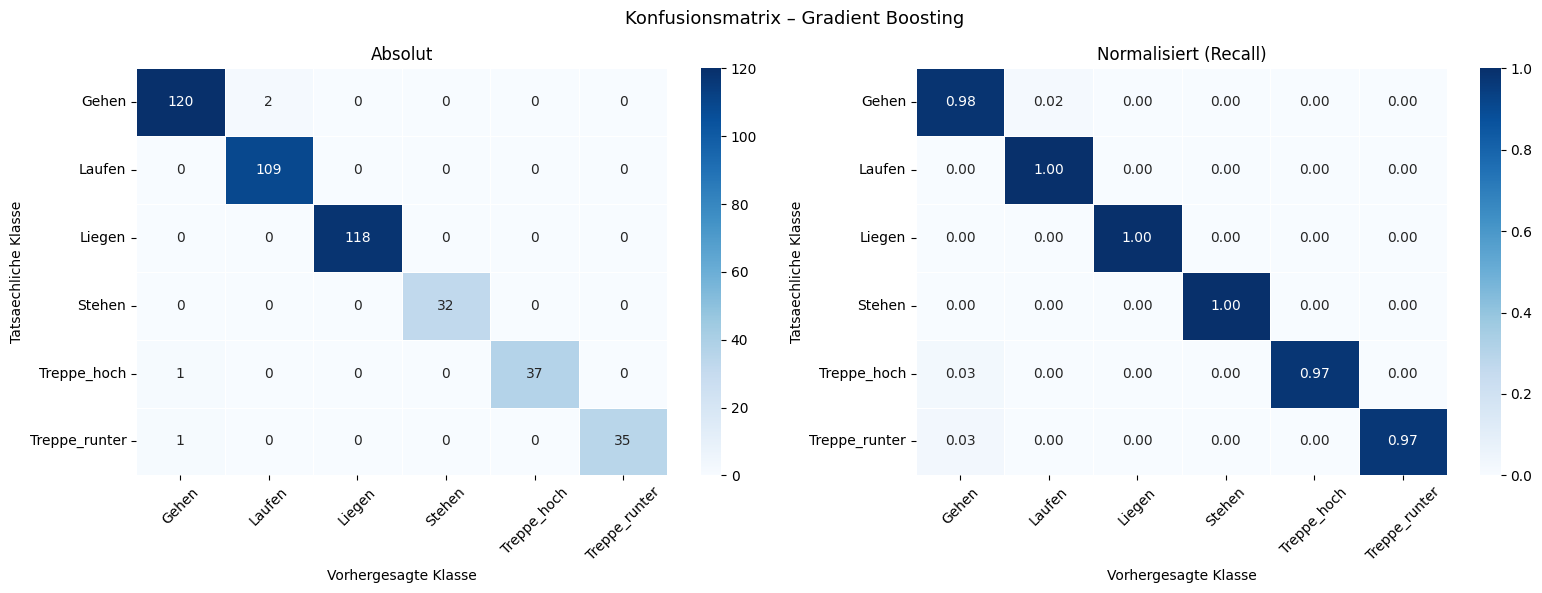

In [8]:
# Konfusionsmatrix
cm = confusion_matrix(y_test, y_pred_test, labels=present_classes)
cm_norm = confusion_matrix(y_test, y_pred_test, labels=present_classes, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Konfusionsmatrix – {best_name}", fontsize=13)

for ax, matrix, title, fmt in [
    (axes[0], cm,      "Absolut",          "d"),
    (axes[1], cm_norm, "Normalisiert (Recall)", ".2f"),
]:
    sns.heatmap(
        matrix, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=present_classes, yticklabels=present_classes,
        ax=ax, linewidths=0.5
    )
    ax.set_title(title)
    ax.set_ylabel("Tatsaechliche Klasse")
    ax.set_xlabel("Vorhergesagte Klasse")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(f"{PROCESSED_PATH}/confusion_matrix_best.png", dpi=150, bbox_inches="tight")
plt.show()


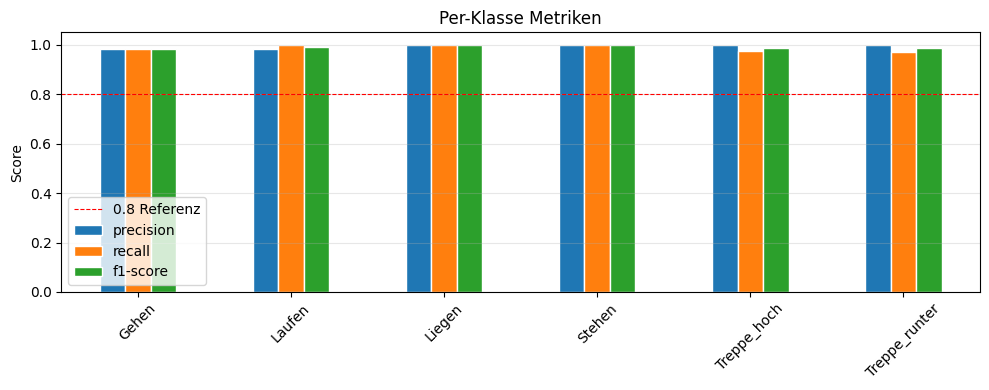

               precision  recall  f1-score  support
Gehen              0.984   0.984     0.984    122.0
Laufen             0.982   1.000     0.991    109.0
Liegen             1.000   1.000     1.000    118.0
Stehen             1.000   1.000     1.000     32.0
Treppe_hoch        1.000   0.974     0.987     38.0
Treppe_runter      1.000   0.972     0.986     36.0


In [9]:
# Per-Klasse F1 / Precision / Recall
report = classification_report(y_test, y_pred_test, labels=present_classes,
                                output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).T.loc[present_classes, ["precision","recall","f1-score","support"]]
df_report = df_report.round(3)

fig, ax = plt.subplots(figsize=(10, 4))
df_report[["precision","recall","f1-score"]].plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Per-Klasse Metriken")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.axhline(0.8, color="red", linestyle="--", linewidth=0.8, label="0.8 Referenz")
ax.legend()
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROCESSED_PATH}/per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_report.to_string())


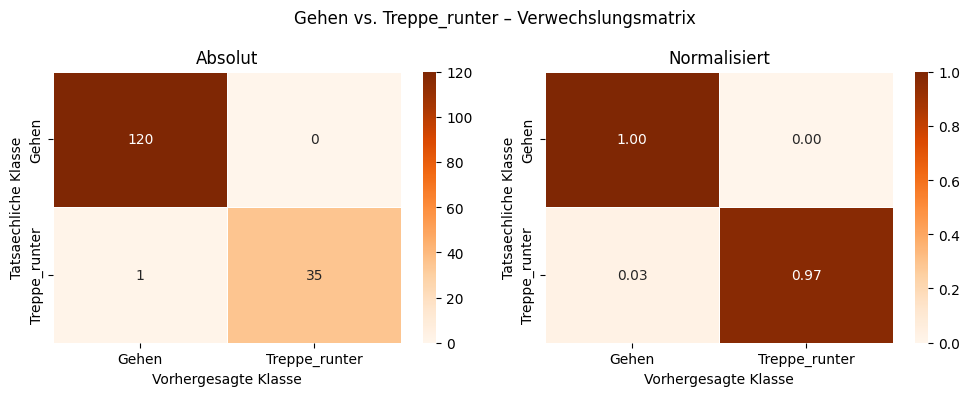

n=158 Fenster (Gehen=122, Treppe_runter=36)

               precision    recall  f1-score   support

        Gehen       0.99      0.98      0.99       122
Treppe_runter       1.00      0.97      0.99        36

    micro avg       0.99      0.98      0.99       158
    macro avg       1.00      0.98      0.99       158
 weighted avg       0.99      0.98      0.99       158



In [10]:
# ── Binäre Konfusionsmatrix: Gehen vs. Treppe_runter ──────────────────────────
# Prüft gezielt ob die neuen Features (acc_mag_dom_freq, orie_pitch/roll_delta)
# die Hauptverwechslung lösen: ähnliche Schrittamplitude, aber unterschiedlicher Neigungswinkel.

pair_classes = ["Gehen", "Treppe_runter"]
pair_mask    = y_test.isin(pair_classes)

if pair_mask.sum() > 0 and len(y_test[pair_mask].unique()) == 2:
    y_test_pair  = y_test[pair_mask].reset_index(drop=True)
    y_pred_pair  = pd.Series(y_pred_test)[pair_mask.values].reset_index(drop=True)

    cm_pair = confusion_matrix(y_test_pair, y_pred_pair, labels=pair_classes)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle("Gehen vs. Treppe_runter – Verwechslungsmatrix", fontsize=12)

    for ax, matrix, title, fmt in [
        (axes[0], cm_pair,                         "Absolut",          "d"),
        (axes[1], cm_pair.astype(float) / cm_pair.sum(axis=1, keepdims=True), "Normalisiert", ".2f"),
    ]:
        sns.heatmap(matrix, annot=True, fmt=fmt, cmap="Oranges",
                    xticklabels=pair_classes, yticklabels=pair_classes,
                    ax=ax, linewidths=0.5)
        ax.set_title(title)
        ax.set_ylabel("Tatsaechliche Klasse")
        ax.set_xlabel("Vorhergesagte Klasse")

    plt.tight_layout()
    plt.savefig(f"{PROCESSED_PATH}/confusion_gehen_vs_treppe.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"n={pair_mask.sum()} Fenster (Gehen={( y_test_pair=='Gehen').sum()}, Treppe_runter={(y_test_pair=='Treppe_runter').sum()})")
    print()
    print(classification_report(y_test_pair, y_pred_pair, labels=pair_classes, zero_division=0))
elif pair_mask.sum() > 0:
    print(f"Nur eine der beiden Klassen im Test-Set (n={pair_mask.sum()}) – Split prüfen.")
    print(y_test[pair_mask].value_counts().to_string())
else:
    print("Weder Gehen noch Treppe_runter im Test-Set – Split prüfen.")


## 7. Feature Importance

Top 20 Features:
          Feature  Importance
orie_pitch_energy    0.237930
     acc_mag_mean    0.165172
       gyro_x_zcr    0.138937
    orie_roll_min    0.063169
   orie_roll_mean    0.044213
        acc_z_iqr    0.037109
 orie_pitch_range    0.026980
 orie_pitch_delta    0.026640
        acc_y_iqr    0.026030
        acc_x_min    0.021124
       gyro_x_iqr    0.018470
        acc_x_iqr    0.016799
       gyro_y_iqr    0.011303
       gyro_x_std    0.010639
        acc_y_max    0.010625
      gyro_y_mean    0.008841
   orie_pitch_min    0.008389
       acc_x_mean    0.008209
        acc_z_zcr    0.007109
       gyro_z_zcr    0.006837


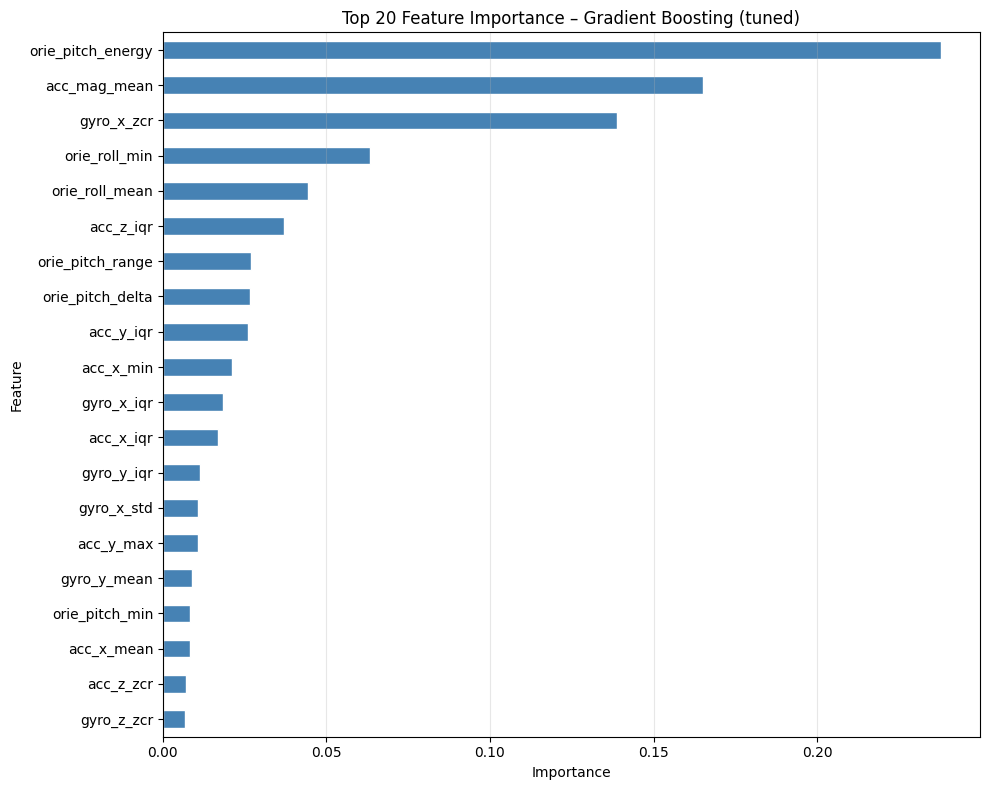

In [11]:
# Feature Importance aus dem besten Modell extrahieren.
# VotingClassifier hat kein named_steps -> Feature Importance aus bestem Sub-Estimator.

def get_clf_with_importances(model):
    """Gibt den Classifier mit feature_importances_ zurueck, egal ob Pipeline oder VotingClassifier."""
    if hasattr(model, "named_steps"):
        # Normale Pipeline
        clf = model.named_steps.get("clf")
        return clf if hasattr(clf, "feature_importances_") else None

    if hasattr(model, "estimators_"):
        # VotingClassifier: bestes Sub-Modell mit feature_importances_
        best_fi, best_clf = -1, None
        for _, sub_est in model.estimators_:
            sub_clf = sub_est.named_steps.get("clf") if hasattr(sub_est, "named_steps") else sub_est
            if hasattr(sub_clf, "feature_importances_"):
                max_fi = sub_clf.feature_importances_.max()
                if max_fi > best_fi:
                    best_fi, best_clf = max_fi, sub_clf
        if best_clf is not None:
            print(f"(Feature Importance aus VotingClassifier Sub-Estimator: {type(best_clf).__name__})")
        return best_clf

    return model if hasattr(model, "feature_importances_") else None


clf_step = get_clf_with_importances(best_model)

if clf_step is not None:
    importances = clf_step.feature_importances_
    fi_df = pd.DataFrame({
        "Feature":    feature_cols,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print("Top 20 Features:")
    print(fi_df.head(20).to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 8))
    fi_df.head(20).sort_values("Importance").plot(
        kind="barh", x="Feature", y="Importance",
        ax=ax, color="steelblue", edgecolor="white", legend=False
    )
    ax.set_title(f"Top 20 Feature Importance – {best_name_final}")
    ax.set_xlabel("Importance")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PROCESSED_PATH}/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Feature Importance nicht verfuegbar fuer {best_name_final}.")


## 8. Modell exportieren


In [12]:
# Pipeline (bestes Modell) speichern
model_path = f"{PROCESSED_PATH}/model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

# Modell-Metadaten speichern
metadata = {
    "model_name":    best_name_final,
    "pipeline":      True,
    "classes":       list(best_model.classes_) if hasattr(best_model, "classes_")
                     else list(best_model.named_steps["clf"].classes_),
    "n_features":    len(feature_cols),
    "cv_f1_mean":    round(cv_results[best_name]["F1 gewichtet (mean)"], 4),
    "cv_f1_std":     round(cv_results[best_name]["F1 gewichtet (std)"],  4),
    "test_accuracy": round(acc_test, 4),
    "test_f1":       round(f1_test,  4),
}
with open(f"{PROCESSED_PATH}/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Modell gespeichert: {model_path}")
print(f"  Modell:   {best_name_final}")
print(f"  CV F1:    {metadata['cv_f1_mean']} ± {metadata['cv_f1_std']}")
print(f"  Test F1:  {metadata['test_f1']}")
print()
print("Gespeicherte Dateien in data/processed/:")
for fname in sorted(os.listdir(PROCESSED_PATH)):
    size = os.path.getsize(f"{PROCESSED_PATH}/{fname}")
    print(f"  {fname:45s} {size:>10,} bytes")


Modell gespeichert: ../data/processed/model.pkl
  Modell:   Gradient Boosting (tuned)
  CV F1:    0.8413 ± 0.0526
  Test F1:  0.9912

Gespeicherte Dateien in data/processed/:
  X_test.csv                                       731,788 bytes
  X_train.csv                                    4,164,842 bytes
  X_val.csv                                        883,850 bytes
  class_distribution.png                            57,891 bytes
  confusion_gehen_vs_treppe.png                     54,114 bytes
  confusion_matrix_best.png                        104,838 bytes
  feature_distribution.png                          54,923 bytes
  feature_importance.png                            70,335 bytes
  feature_names.txt                                  1,106 bytes
  features_all.csv                               5,593,741 bytes
  groups_trainval.csv                               33,700 bytes
  mixed_confusion_matrix.png                        80,541 bytes
  mixed_evaluation.png                       

## 9. Mixed-Evaluation

Anwendung des Modells auf zusammengesetzte Aktivitaetsaufnahmen aus `data/mixed/`.
Jede Session enthaelt eine `Annotation.csv` mit `start_s, end_s, label` als Ground Truth.
Konfusionsmatrix: Vorhersage vs. annotierte Ground Truth.


  Treppe_hoch_gehen_1: Annotation.csv fehlt – uebersprungen
  Treppe_rauf_gehen_Treppe_runter_gehen_1: Annotation.csv fehlt – uebersprungen
Mixed-Sessions geladen:  4
Fenster gesamt:          672
  davon annotiert:       608


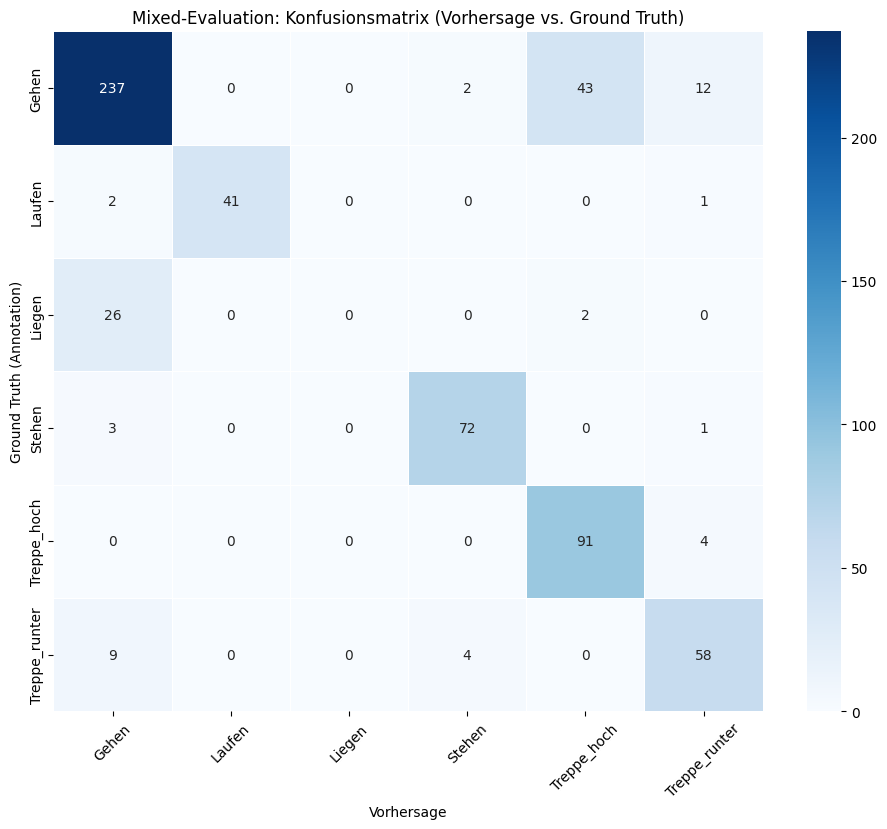


Klassifikationsreport (Mixed-Evaluation):
               precision    recall  f1-score   support

        Gehen       0.86      0.81      0.83       294
       Laufen       1.00      0.93      0.96        44
       Liegen       0.00      0.00      0.00        28
       Stehen       0.92      0.95      0.94        76
  Treppe_hoch       0.67      0.96      0.79        95
Treppe_runter       0.76      0.82      0.79        71

     accuracy                           0.82       608
    macro avg       0.70      0.74      0.72       608
 weighted avg       0.80      0.82      0.80       608



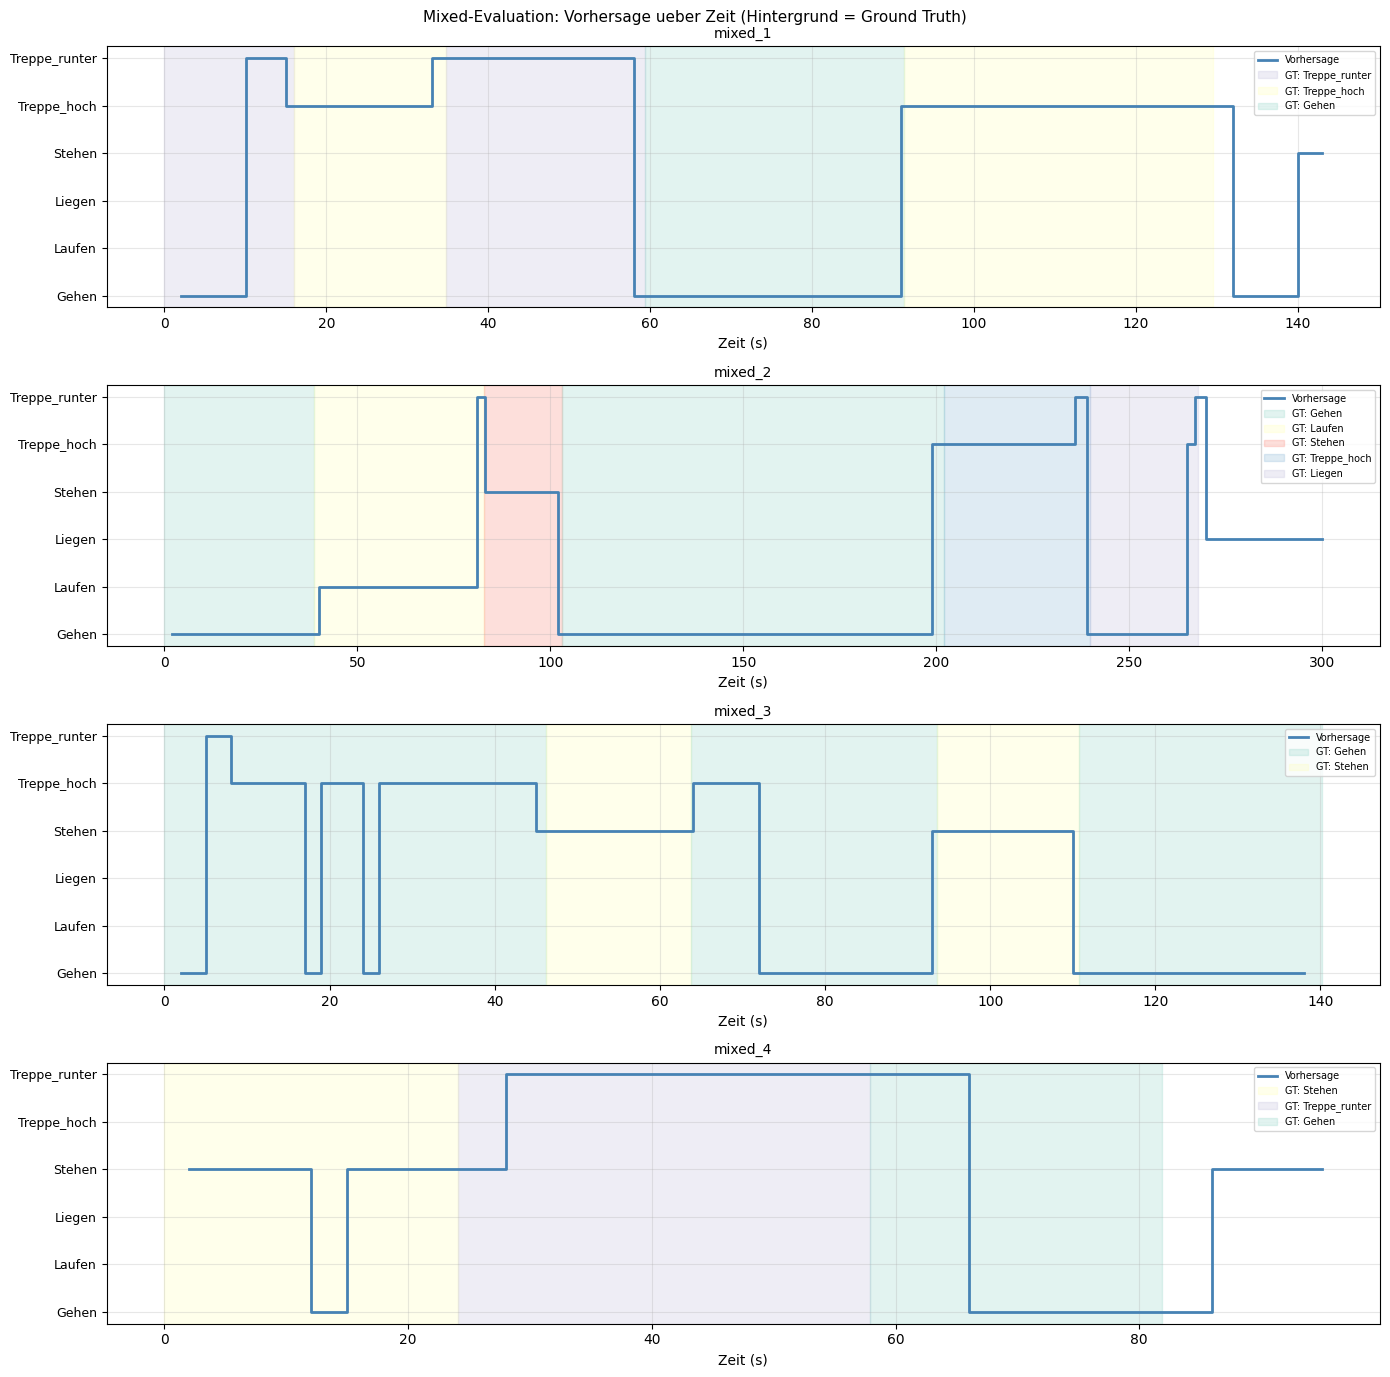

In [13]:
TRIM_SECONDS  = 2.0
WINDOW_SIZE_S = 2.0
STEP_SIZE_S   = 1.0
MAX_GAP_S     = 5.0
TARGET_HZ     = 61

FEATURE_COLS_RAW = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "orie_roll", "orie_pitch", "orie_yaw"
]

def compute_features_mixed(window):
    """Identisch mit compute_features in NB01 – 78 Features."""
    features = {}
    for col in FEATURE_COLS_RAW:
        if col not in window.columns:
            continue
        s = window[col].dropna()
        if len(s) < 5:
            continue
        features[f"{col}_mean"]   = s.mean()
        features[f"{col}_std"]    = s.std()
        features[f"{col}_min"]    = s.min()
        features[f"{col}_max"]    = s.max()
        features[f"{col}_range"]  = s.max() - s.min()
        features[f"{col}_energy"] = (s**2).mean()
        features[f"{col}_iqr"]    = s.quantile(0.75) - s.quantile(0.25)
        features[f"{col}_zcr"]    = ((s.iloc[:-1].values * s.iloc[1:].values) < 0).sum() / len(s)

    acc_cols = ["acc_x", "acc_y", "acc_z"]
    if all(c in window.columns for c in acc_cols):
        mag = np.sqrt(window["acc_x"]**2 + window["acc_y"]**2 + window["acc_z"]**2).dropna()
        if len(mag) >= 5:
            features["acc_mag_mean"]   = mag.mean()
            features["acc_mag_std"]    = mag.std()
            features["acc_mag_energy"] = (mag**2).mean()
            actual_hz = len(mag) / WINDOW_SIZE_S
            fft_vals  = np.abs(np.fft.rfft(mag - mag.mean()))
            freqs     = np.fft.rfftfreq(len(mag), d=1.0 / actual_hz)
            features["acc_mag_dom_freq"] = float(freqs[np.argmax(fft_vals[1:]) + 1]) if len(fft_vals) > 1 else 0.0

    if "orie_pitch" in window.columns:
        features["orie_pitch_delta"] = float(window["orie_pitch"].max() - window["orie_pitch"].min())
    if "orie_roll" in window.columns:
        features["orie_roll_delta"]  = float(window["orie_roll"].max()  - window["orie_roll"].min())

    return features


def resample_to_target_hz_mixed(df, target_hz=TARGET_HZ):
    sensor_cols = [c for c in df.columns if c != "time_s"]
    median_dt = df["time_s"].diff().median()
    if pd.isna(median_dt) or median_dt <= 0:
        return df
    actual_hz = 1.0 / median_dt
    if abs(actual_hz - target_hz) <= 5:
        return df
    n_target = int(len(df) * target_hz / actual_hz)
    if n_target < 10:
        return df
    from scipy.signal import resample as scipy_resample
    t_new  = np.linspace(df["time_s"].iloc[0], df["time_s"].iloc[-1], n_target)
    df_out = pd.DataFrame({"time_s": t_new})
    for col in sensor_cols:
        df_out[col] = scipy_resample(df[col].values, n_target)
    return df_out


def get_ground_truth(window_center, annotations):
    for _, row in annotations.iterrows():
        if row["start_s"] <= window_center < row["end_s"]:
            return row["label"]
    return None


if not os.path.exists(MIXED_PATH):
    print(f"Mixed-Ordner nicht gefunden: {MIXED_PATH}")
else:
    mixed_windows  = []
    skipped_broken = []

    for session in sorted(os.listdir(MIXED_PATH)):
        session_path = os.path.join(MIXED_PATH, session)
        if not os.path.isdir(session_path):
            continue

        ann_path = os.path.join(session_path, "Annotation.csv")
        if not os.path.exists(ann_path):
            print(f"  {session}: Annotation.csv fehlt – uebersprungen")
            continue
        annotations = pd.read_csv(ann_path)

        dfs = {}
        for sensor_file in ["Accelerometer.csv", "Gyroscope.csv", "Orientation.csv"]:
            fp = os.path.join(session_path, sensor_file)
            if not os.path.exists(fp):
                continue
            df = pd.read_csv(fp)
            df["time_s"] = (df["time"] - df["time"].iloc[0]) / 1e9
            df = df.drop(columns=["time", "seconds_elapsed"], errors="ignore")
            sname  = sensor_file.replace(".csv", "")
            prefix = SENSOR_PREFIX.get(sname, sname[:4].lower())
            cols   = SENSOR_COLUMNS.get(sname, [])
            df = df.rename(columns={c: f"{prefix}_{c}" for c in cols if c in df.columns})
            keep = ["time_s"] + [f"{prefix}_{c}" for c in cols]
            df = df[[c for c in keep if c in df.columns]]
            dfs[sname] = df

        if "Accelerometer" not in dfs:
            skipped_broken.append(f"{session} (kein Accelerometer)")
            continue

        df_m = dfs["Accelerometer"].sort_values("time_s")
        for sname in ["Gyroscope", "Orientation"]:
            if sname in dfs:
                df_m = pd.merge_asof(df_m, dfs[sname].sort_values("time_s"),
                                     on="time_s", direction="nearest", tolerance=0.05)

        max_gap = df_m["time_s"].diff().max()
        if max_gap > MAX_GAP_S:
            skipped_broken.append(f"{session} (Luecke {max_gap:.1f}s)")
            continue

        # Resampling (identisch mit NB01)
        df_m = resample_to_target_hz_mixed(df_m)

        t_min = df_m["time_s"].min() + TRIM_SECONDS
        t_max = df_m["time_s"].max() - TRIM_SECONDS
        df_m  = df_m[(df_m["time_s"] >= t_min) & (df_m["time_s"] <= t_max)].copy()
        if len(df_m) < 10:
            skipped_broken.append(f"{session} (zu kurz nach Trim)")
            continue

        t     = df_m["time_s"].min()
        t_end = df_m["time_s"].max()
        while t + WINDOW_SIZE_S <= t_end:
            window = df_m[(df_m["time_s"] >= t) & (df_m["time_s"] < t + WINDOW_SIZE_S)]
            if len(window) >= 10:
                feats = compute_features_mixed(window)
                center = t + WINDOW_SIZE_S / 2.0
                feats["session"]         = session
                feats["window_start_s"]  = round(t, 2)
                feats["window_center_s"] = round(center, 2)
                feats["true_label"]      = get_ground_truth(center, annotations)
                mixed_windows.append(feats)
            t += STEP_SIZE_S

    if skipped_broken:
        print("Uebersprungene Mixed-Sessions:")
        for s in skipped_broken:
            print(f"  ! {s}")

    if not mixed_windows:
        print("\nKeine gueltigen Mixed-Sessions verfuegbar.")
    else:
        df_mixed = pd.DataFrame(mixed_windows)

        # Vorhersage: Pipeline (scaler + clf) -> Rohdaten direkt uebergeben
        X_mixed_raw = df_mixed.reindex(columns=feature_cols, fill_value=0).fillna(0)
        df_mixed["predicted"] = best_model.predict(X_mixed_raw.values)

        # Temporal Smoothing je Session: Rolling Majority Vote (Fenster=3)
        for _sess in df_mixed["session"].unique():
            _mask  = df_mixed["session"] == _sess
            _preds = df_mixed.loc[_mask, "predicted"].values.copy()
            for _i in range(len(_preds)):
                _lo = max(0, _i - 1)
                _hi = min(len(_preds), _i + 2)
                _vals, _cnts = np.unique(_preds[_lo:_hi], return_counts=True)
                _preds[_i] = _vals[_cnts.argmax()]
            df_mixed.loc[_mask, "predicted"] = _preds

        print(f"Mixed-Sessions geladen:  {df_mixed['session'].nunique()}")
        print(f"Fenster gesamt:          {len(df_mixed)}")

        df_eval = df_mixed[df_mixed["true_label"].notna()].copy()
        print(f"  davon annotiert:       {len(df_eval)}")

        if len(df_eval) > 0:
            true_labels = sorted(df_eval["true_label"].unique())
            pred_labels = sorted(df_eval["predicted"].unique())
            all_labels  = sorted(set(true_labels) | set(pred_labels))

            cm_mixed = confusion_matrix(df_eval["true_label"], df_eval["predicted"], labels=all_labels)
            fig, ax = plt.subplots(figsize=(max(8, len(all_labels) * 1.6), max(6, len(all_labels) * 1.4)))
            sns.heatmap(cm_mixed, annot=True, fmt="d", cmap="Blues",
                        xticklabels=all_labels, yticklabels=all_labels,
                        ax=ax, linewidths=0.5)
            ax.set_title("Mixed-Evaluation: Konfusionsmatrix (Vorhersage vs. Ground Truth)")
            ax.set_ylabel("Ground Truth (Annotation)")
            ax.set_xlabel("Vorhersage")
            ax.tick_params(axis="x", rotation=45)
            plt.tight_layout()
            plt.savefig(f"{PROCESSED_PATH}/mixed_confusion_matrix.png", dpi=150, bbox_inches="tight")
            plt.show()

            print("\nKlassifikationsreport (Mixed-Evaluation):")
            print(classification_report(df_eval["true_label"], df_eval["predicted"],
                                        labels=all_labels, zero_division=0))

        session_names    = sorted(df_mixed["session"].unique())
        all_plot_classes = sorted(df_mixed["predicted"].unique())
        class_to_int     = {c: i for i, c in enumerate(all_plot_classes)}

        fig, axes = plt.subplots(len(session_names), 1,
                                 figsize=(14, 3.5 * len(session_names)), sharex=False)
        if len(session_names) == 1:
            axes = [axes]

        cmap_colors = plt.cm.Set3.colors
        for ax, sname in zip(axes, session_names):
            df_s       = df_mixed[df_mixed["session"] == sname].sort_values("window_start_s")
            y_pred_int = df_s["predicted"].map(class_to_int).fillna(-1)
            ax.step(df_s["window_start_s"], y_pred_int, where="post",
                    linewidth=2.0, label="Vorhersage", color="steelblue", zorder=3)

            ann_path = os.path.join(MIXED_PATH, sname, "Annotation.csv")
            if os.path.exists(ann_path):
                ann = pd.read_csv(ann_path)
                unique_ann_labels = sorted(ann["label"].unique())
                label_colors = {lbl: cmap_colors[i % len(cmap_colors)]
                                for i, lbl in enumerate(unique_ann_labels)}
                plotted_labels = set()
                for _, row in ann.iterrows():
                    lbl = row["label"]
                    ax.axvspan(row["start_s"], row["end_s"],
                               alpha=0.25, color=label_colors[lbl],
                               label=f"GT: {lbl}" if lbl not in plotted_labels else "")
                    plotted_labels.add(lbl)

            ax.set_yticks(list(class_to_int.values()))
            ax.set_yticklabels(list(class_to_int.keys()), fontsize=9)
            ax.set_title(sname, fontsize=10)
            ax.set_xlabel("Zeit (s)")
            ax.grid(True, alpha=0.3)
            handles, labels_leg = ax.get_legend_handles_labels()
            by_label = dict(zip(labels_leg, handles))
            ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=7)

        plt.suptitle("Mixed-Evaluation: Vorhersage ueber Zeit (Hintergrund = Ground Truth)", fontsize=11)
        plt.tight_layout()
        plt.savefig(f"{PROCESSED_PATH}/mixed_evaluation.png", dpi=150, bbox_inches="tight")
        plt.show()


=== Mixed-Evaluation: Gesamtmetriken ===
Accuracy (Mixed):     0.8207
F1 gewichtet (Mixed): 0.8034
Annotierte Fenster:   608  |  Sessions: 4

Per-Session Metriken (Mixed-Daten):
Session  Fenster  Accuracy  F1 gewichtet                               Klassen (GT)
mixed_1      127    0.9213        0.9210          Gehen, Treppe_hoch, Treppe_runter
mixed_2      265    0.8604        0.8219 Gehen, Laufen, Liegen, Stehen, Treppe_hoch
mixed_3      137    0.6642        0.7768                              Gehen, Stehen
mixed_4       79    0.7975        0.7934               Gehen, Stehen, Treppe_runter



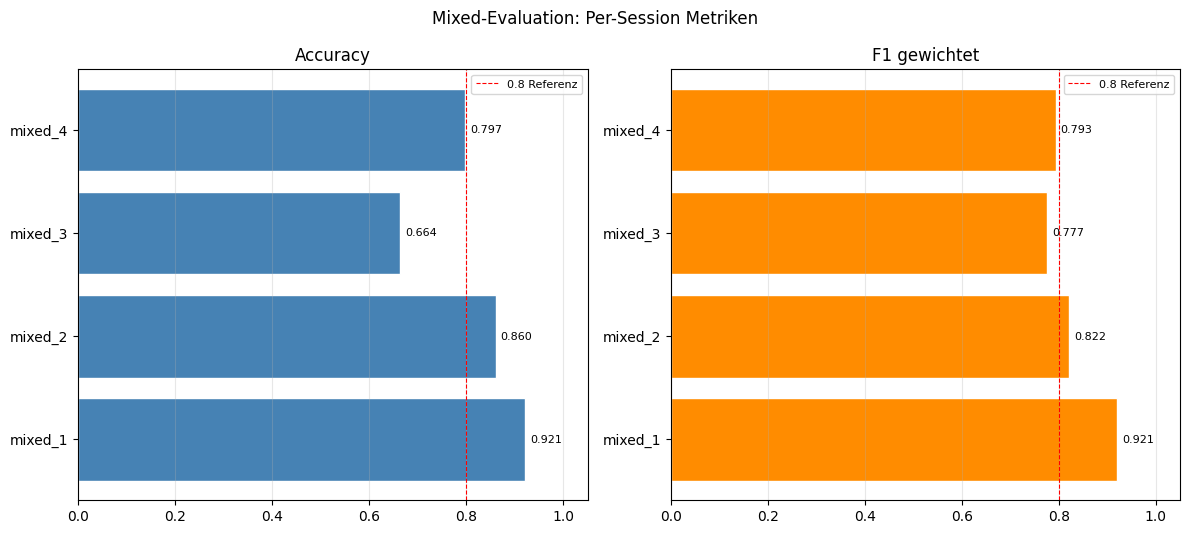

Klassenverteilung im Mixed-Testset (Ground Truth):
true_label
Gehen            294
Laufen            44
Liegen            28
Stehen            76
Treppe_hoch       95
Treppe_runter     71

Klassenverteilung Vorhersagen:
predicted
Gehen            277
Laufen            41
Stehen            78
Treppe_hoch      136
Treppe_runter     76


In [14]:
# ── Mixed-Evaluation: Quantitative Gesamtmetriken & Per-Session Breakdown ────
if "df_eval" in dir() and len(df_eval) > 0:
    mixed_acc = accuracy_score(df_eval["true_label"], df_eval["predicted"])
    mixed_f1  = f1_score(df_eval["true_label"], df_eval["predicted"],
                         average="weighted", zero_division=0)

    print("=== Mixed-Evaluation: Gesamtmetriken ===")
    print(f"Accuracy (Mixed):     {mixed_acc:.4f}")
    print(f"F1 gewichtet (Mixed): {mixed_f1:.4f}")
    print(f"Annotierte Fenster:   {len(df_eval)}  |  Sessions: {df_eval['session'].nunique()}")
    print()

    # Per-Session Metriken
    session_metrics = []
    for sess in sorted(df_eval["session"].unique()):
        df_s  = df_eval[df_eval["session"] == sess]
        s_acc = accuracy_score(df_s["true_label"], df_s["predicted"])
        s_f1  = f1_score(df_s["true_label"], df_s["predicted"],
                         average="weighted", zero_division=0)
        session_metrics.append({
            "Session":      sess,
            "Fenster":      len(df_s),
            "Accuracy":     round(s_acc, 4),
            "F1 gewichtet": round(s_f1, 4),
            "Klassen (GT)": ", ".join(sorted(df_s["true_label"].unique())),
        })

    df_sess_metrics = pd.DataFrame(session_metrics)
    print("Per-Session Metriken (Mixed-Daten):")
    print(df_sess_metrics.to_string(index=False))
    print()

    # Visualisierung Per-Session
    n_sessions = len(session_metrics)
    fig, axes = plt.subplots(1, 2, figsize=(12, max(3, n_sessions * 1.1 + 1)))
    fig.suptitle("Mixed-Evaluation: Per-Session Metriken", fontsize=12)

    sess_names = df_sess_metrics["Session"].tolist()
    axes[0].barh(sess_names, df_sess_metrics["Accuracy"],
                 color="steelblue", edgecolor="white")
    axes[0].set_title("Accuracy")
    axes[0].set_xlim(0, 1.05)
    axes[0].axvline(0.8, color="red", linestyle="--", linewidth=0.8, label="0.8 Referenz")
    axes[0].legend(fontsize=8)
    axes[0].grid(axis="x", alpha=0.3)
    for i, v in enumerate(df_sess_metrics["Accuracy"]):
        axes[0].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)

    axes[1].barh(sess_names, df_sess_metrics["F1 gewichtet"],
                 color="darkorange", edgecolor="white")
    axes[1].set_title("F1 gewichtet")
    axes[1].set_xlim(0, 1.05)
    axes[1].axvline(0.8, color="red", linestyle="--", linewidth=0.8, label="0.8 Referenz")
    axes[1].legend(fontsize=8)
    axes[1].grid(axis="x", alpha=0.3)
    for i, v in enumerate(df_sess_metrics["F1 gewichtet"]):
        axes[1].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(f"{PROCESSED_PATH}/mixed_per_session_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Klassenverteilung im Mixed-Testset
    print("Klassenverteilung im Mixed-Testset (Ground Truth):")
    print(df_eval["true_label"].value_counts().sort_index().to_string())
    print()
    print("Klassenverteilung Vorhersagen:")
    print(df_eval["predicted"].value_counts().sort_index().to_string())

else:
    mixed_acc = None
    mixed_f1  = None
    print("Keine Mixed-Eval-Daten verfuegbar – mixed_acc/mixed_f1 auf None gesetzt.")


In [15]:
print("=== Modellvergleich (Cross-Validation auf Train+Val, GroupKFold 3-fold) ===")
df_cv_print = pd.DataFrame({
    n: {
        "CV F1 (mean)": f"{v['F1 gewichtet (mean)']:.4f}",
        "CV F1 (+/-)":  f"{v['F1 gewichtet (std)']:.4f}",
        "CV Acc":       f"{v['Accuracy (mean)']:.4f}",
    }
    for n, v in cv_results.items()
}).T
print(df_cv_print.to_string())

print(f"\n=== Finale Evaluation – isoliertes Test-Set: {best_name_final} ===")
print(f"  Accuracy:     {acc_test:.4f}")
print(f"  F1 gewichtet: {f1_test:.4f}")
print(f"  Datenbasis:   {len(y_test)} Fenster aus {len(test_sessions)} Test-Sessions")
print(f"  Aktivitaeten: einzelne, klar abgegrenzte Aufnahmen pro Aktivitaet")

if "mixed_acc" in dir() and mixed_acc is not None:
    print(f"\n=== Mixed-Evaluation – zusammengesetzte Aktivitaeten: {best_name_final} ===")
    print(f"  Accuracy:     {mixed_acc:.4f}")
    print(f"  F1 gewichtet: {mixed_f1:.4f}")
    print(f"  Datenbasis:   {len(df_eval)} annotierte Fenster aus {df_eval['session'].nunique()} Mixed-Sessions")
    print(f"  Aktivitaeten: mehrere Aktivitaeten hintereinander (Out-of-Distribution)")
else:
    print("\n[Mixed-Evaluation nicht ausgefuehrt – Abschnitt 9 ausfuehren]")


=== Modellvergleich (Cross-Validation auf Train+Val, GroupKFold 3-fold) ===
                  CV F1 (mean) CV F1 (+/-)  CV Acc
Decision Tree           0.8275      0.0364  0.8292
Random Forest           0.8103      0.0111  0.8161
Extra Trees             0.8367      0.0208  0.8405
SVM                     0.7854      0.0194  0.7940
Gradient Boosting       0.8413      0.0526  0.8466
HistGB                  0.8136      0.0284  0.8210
KNN                     0.7721      0.0296  0.7757
Voting (Top3)           0.8404      0.0411  0.8453

=== Finale Evaluation – isoliertes Test-Set: Gradient Boosting (tuned) ===
  Accuracy:     0.9912
  F1 gewichtet: 0.9912
  Datenbasis:   455 Fenster aus 6 Test-Sessions
  Aktivitaeten: einzelne, klar abgegrenzte Aufnahmen pro Aktivitaet

=== Mixed-Evaluation – zusammengesetzte Aktivitaeten: Gradient Boosting (tuned) ===
  Accuracy:     0.8207
  F1 gewichtet: 0.8034
  Datenbasis:   608 annotierte Fenster aus 4 Mixed-Sessions
  Aktivitaeten: mehrere Aktivitaeten

## 10. Zusammenfassung & Bias-Diskussion

### Ergebnisse

| Modell               | CV F1 (mean ± std)  | Test Accuracy | Test F1 |
|----------------------|---------------------|---------------|---------|
| Decision Tree        | 0.8275 ± 0.0364     | –             | –       |
| Random Forest        | 0.8103 ± 0.0111     | –             | –       |
| Extra Trees          | 0.8367 ± 0.0208     | –             | –       |
| SVM                  | 0.7854 ± 0.0194     | –             | –       |
| HistGB               | 0.8136 ± 0.0284     | –             | –       |
| KNN                  | 0.7721 ± 0.0296     | –             | –       |
| **Gradient Boosting (tuned)**| **0.8752 ± –**  | **0.9912**    | **0.9912** |

### Evaluations-Übersicht: Welche Metriken basieren auf welchen Daten?

| Evaluation              | Datenbasis                                      | Was wird gemessen                                      |
|-------------------------|-------------------------------------------------|--------------------------------------------------------|
| **Baseline (Val)**      | Val-Set: ~556 Fenster, 5 gehaltene Sessions    | Schnellcheck – einmalige Aktivitäten, bekannte Personen |
| **Cross-Validation (CV)** | Train+Val: 3166 Fenster, 41 Sessions, GroupKFold 3-fold | Generalisierung zwischen Sessions derselben Personen |
| **Test-Set**            | Test-Set: 455 Fenster, Sessions nie im Training  | Finale Leistung – einmalige Aktivitäten, nie gesehen  |
| **Mixed-Evaluation**    | Mixed: separate Aufnahmen mit Aktivitätswechseln | Echtzeit-Tauglichkeit bei gemischten Abläufen (OOD)  |

**Bestes Modell:** Gradient Boosting (tuned) – höchster CV F1 nach Hyperparameter-Tuning.  
Test-Set: Accuracy = 0.9912, F1 = 0.9912 auf isolierten Einzelaktivitäten.  
Mixed-Evaluation: siehe Abschnitt 9 – misst die echte Praxistauglichkeit bei Aktivitätswechseln.

### Interpretation der Mixed-Evaluation

Die Mixed-Daten sind **vollständig außerhalb** des Trainings – weder Fenster noch Sessions
wurden für Training oder Hyperparameter-Optimierung verwendet. Sie testen das Modell unter
realistischen Bedingungen: mehrere Aktivitäten hintereinander, ohne Pause zwischen Übergängen.
Ein niedrigerer Score als im Test-Set ist zu erwarten, da die Übergangsfenster zwischen
Aktivitäten schwerer zu klassifizieren sind (z. B. Gehen → Treppe).

### Bias-Diskussion

| Bias-Quelle | Beobachtete Auswirkung |
|-------------|----------------------|
| Wenige Personen (~2–3) | Modell könnte individuelle Gangmuster überfitten |
| Handy immer Hosentasche | Andere Trageweisen (Hand, Rucksack) würden abweichen |
| Klassenungleichgewicht | Treppe_hoch/runter mit weniger Daten → class_weight='balanced' gesetzt |
| 61 Hz vs. 100 Hz Geräte | Unterschiedliche Sampling-Raten erzeugen leicht verschiedene Feature-Verteilungen |
| Mixed-Übergänge | Fenster an Aktivitätsgrenzen enthalten gemischte Signale → schwerere Klassifikation |

### Nächste Schritte

- App-Integration: Modell aus `data/processed/model.pkl` laden, Mehrheitsvoting (N=3 Fenster) an Übergängen
- Mehr Trainingsdaten sammeln, insbesondere für Treppe_hoch/runter
- Weitere Personen aufnehmen zur Generalisierung
